# Node2 - GeneralVariableScan
Valid for single node experiments using AllSPCMs from 2026-07 until ...


In [31]:
date_filters = ["2026-08-20", "2026-08-21"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time

from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files
# from h5_data_utilities_node1 import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan", "MicrowaveScanOptimizer"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")
# ============================================================
# Microwave fitting functions
# ============================================================

def Rabi_oscillation_fit(t, r, f, C, tau):
    """Exponentially damped Rabi oscillation; f is Omega/(2*pi)."""
    asymptote = r - C / 2
    return (C / 2) * np.cos(2 * np.pi * f * t) * np.exp(-t / np.abs(tau)) + asymptote


def Rabi_oscillation_with_offset_fit(t, t0, r, f, C, tau):
    """Exponentially damped Rabi oscillation with a fitted time offset."""
    asymptote = r - C / 2
    return (C / 2) * np.cos(2 * np.pi * f * (t - t0)) * np.exp(-(t - t0) / np.abs(tau)) + asymptote


def inverted_Rabi_oscillation_with_offset_fit(t, t0, r, f, C, tau):
    """Damped Rabi oscillation that starts at minimum retention, as in the MW-RF sequence."""
    asymptote = r - C / 2
    elapsed = np.maximum(t - t0, 0)
    return asymptote - (C / 2) * np.cos(2 * np.pi * f * (t - t0)) * np.exp(-elapsed / np.abs(tau))


def resonance_dip_fit(f, r, sigma, f0, C):
    """Gaussian resonance dip with baseline r and fractional contrast C."""
    return r * (1 - C * np.exp(-0.5 * ((f - f0) / sigma) ** 2))


def resonance_positive_dip_fit(f, r, sigma, f0, C):
    """Gaussian resonance peak with baseline r."""
    return r + C * np.exp(-0.5 * ((f - f0) / sigma) ** 2)


def resonance_positive_dip_fit2(f, sigma, f0, C):
    """Gaussian resonance peak without an explicit baseline."""
    return C * np.exp(-0.5 * ((f - f0) / sigma) ** 2)


def Ramsey_oscillation_fit(t, t0, r, f, C, sigma):
    """Ramsey oscillation with a Gaussian coherence envelope."""
    return (r / 2) - (C / 2) * np.cos(2 * np.pi * f * (t - t0)) * np.exp(-0.5 * ((t - t0) / sigma) ** 2)


def Ramsey_exp_cos_fit(t, A, offset, phase, T2s, f_detuning, expon):
    """Ramsey oscillation with a stretched-exponential coherence envelope."""
    return offset + A * np.exp(-(t / T2s) ** expon) * np.cos(2 * np.pi * f_detuning * t + phase)


SCAN_FLAGS = [
    "Frequency_00_Scan", "Frequency_01_Scan", "Frequency_11_Scan", "Frequency_m10_Scan",
    "Time_00_Scan", "Time_01_Scan", "Time_11_Scan", "Time_m10_Scan",
    "Ramsey_00_Scan", "Ramsey_01_Scan", "Ramsey_11_Scan",
]


def reset_scan_flags(local_ns):
    """Reset scan flags before loading each file so flags cannot leak between files."""
    for name in SCAN_FLAGS:
        local_ns[name] = False


def ensure_scan_flags_in_locals(local_ns):
    """Create any scan flags that are absent from an older HDF5 file."""
    for name in SCAN_FLAGS:
        local_ns.setdefault(name, False)


def ensure_scan_flags(scope):
    """Backward-compatible alias used by older analysis cells."""
    ensure_scan_flags_in_locals(scope)


def _scan_flag(local_ns, name):
    value = local_ns.get(name, False)
    try:
        return bool(np.asarray(value).squeeze())
    except (TypeError, ValueError):
        return False


def get_scan_fit_guess_from_locals(local_ns, verbose=True):
    """Return the transition-dependent resonance center and Gaussian sigma guesses."""
    settings = [
        ("Frequency_00_Scan", "Frequency_00_Scan with pi pulse", 334.66e6, 80e3),
        ("Frequency_01_Scan", "Frequency_01_Scan with pi pulse", 336.95e6, 60e3),
        ("Frequency_11_Scan", "Frequency_11_Scan with pi pulse", 339.34e6, 50e3),
        ("Frequency_m10_Scan", "Frequency_m10_Scan with pi pulse", 332.30e6, 50e3),
        ("Time_00_Scan", "Time_00_Scan", 70e3, None),
        ("Time_01_Scan", "Time_01_Scan", 100e3, None),
        ("Time_11_Scan", "Time_11_Scan", None, None),
        ("Time_m10_Scan", "Time_m10_Scan", None, None),
        ("Ramsey_00_Scan", "Ramsey_00_Scan", None, None),
        ("Ramsey_01_Scan", "Ramsey_01_Scan", None, None),
        ("Ramsey_11_Scan", "Ramsey_11_Scan", None, None),
    ]
    for flag_name, message, frequency, sigma in settings:
        if _scan_flag(local_ns, flag_name):
            if verbose:
                print(message)
            return frequency, sigma
    if verbose:
        print("No recognized microwave scan flag found; using the default fit guess for the scanned variable.")
    return None, None


def get_scan_fit_guess(scope):
    """Backward-compatible alias used by older analysis cells."""
    return get_scan_fit_guess_from_locals(scope)


def print_if_exists(local_ns, name, scale=1.0, unit=""):
    """Print an experiment variable only when it exists in the loaded file."""
    if name in local_ns:
        print(f"{name}: {local_ns[name] * scale} {unit}")


def safe_print(name, scope, scale=1.0, unit=""):
    """Backward-compatible alias used by older analysis cells."""
    print_if_exists(scope, name, scale=scale, unit=unit)


def build_fit_dict(fit_for_this_freq=None, fit_for_this_sigma=None):
    """Build all microwave/RF frequency, Rabi-time, and Ramsey fit specifications."""
    fit_dict = {
        "f_MW_RF_dds": {
            "model": resonance_dip_fit,
            "p0": [0.9, 50e3, 2.3e6, 0.9],
            "params": ["r", "sigma", "f0", "C"],
            "bounds": (-np.inf, np.inf),
        },
        "f_microwaves_11_dds": {
            "model": resonance_positive_dip_fit2,
            "p0": [50e3, 340e6, 1.0],
            "params": ["sigma", "f0", "C"],
            "bounds": (-np.inf, np.inf),
        },
        "f_microwaves_m11_dds": {
            "model": resonance_positive_dip_fit,
            "p0": [0.08, 7e3, 331.92e6, 0.82],
            "params": ["r", "sigma", "f0", "C"],
            "bounds": ([0.0, 1e3, 331.88e6, 0.0],[0.3, 30e3, 331.98e6, 1.0],),
        },
        "t_microwave_pulse": {
            "model": Rabi_oscillation_fit,
            "p0": [1.0, 100e3, 1.0, 1e-3],
            "params": ["r", "Omega/2*pi", "C", "tau"],
            "bounds": ([0.8, 50e3, 0.8, 1e-6], [1.0, 150e3, 1.0, 100e-3]),
        },
        "f_microwaves_11_dds" : {
            "model": resonance_positive_dip_fit,
            "p0": [0.1, 50e3, 339e6, 0.8],
            "params": ["r", "sigma", "f0", "C"],
            "bounds": (
                [0.0, 10e3, 339e6 - 100e3, 0.0],
                [0.3, 100e3, 339e6 + 100e3, 1.0],
            ),
        },
        "t_microwave_m10_pulse": {
            "model": Rabi_oscillation_with_offset_fit,
            "p0": [9e-6, 1.0, 70e3, 1.0, 1e-4],
            "params": ["t0", "r", "Omega/2*pi", "C", "tau"],
            "bounds": ([4e-6, 0.8, 20e3, 0.8, 1e-5], [15e-6, 1.0, 100e3, 1.0, 1e-3]),
        },
        "t_microwave_11_pulse": {
            "model": Rabi_oscillation_with_offset_fit,
            "p0": [9e-6, 1.0, 70e3, 1.0, 1e-4],
            "params": ["t0", "r", "Omega/2*pi", "C", "tau"],
            "bounds": ([4e-6, 0.8, 20e3, 0.8, 1e-5], [15e-6, 1.0, 100e3, 1.0, 1e-3]),
        },
        "t_MW_RF_pulse": {
            "model": inverted_Rabi_oscillation_with_offset_fit,
            "p0": [0.0, 0.9, 2.0e3, 0.85, 5e-3],
            "params": ["t0", "r", "Omega/2*pi", "C", "tau"],
            "bounds": ([-20e-6, 0.6, 0.5e3, 0.4, 0.3e-3], [ 20e-6, 1.0, 4.0e3, 1.0, 50e-3],),
        },
        "t_delay_between_shots": {
            "model": Ramsey_exp_cos_fit,
            "p0": [0.5, 0.5, 3.14, 3e-3, 25e3, 2.0],
            "params": ["amplitude", "offset", "phase", "T2s", "f_detuning", "expon"],
            "bounds": ([0.2, 0.2, -2*np.pi, 1e-4, 10e3, 1.0], [0.6, 0.6, 2*np.pi, 1e-2, 30e3, 2.1]),
        },
    }

    if fit_for_this_freq is not None and fit_for_this_sigma is None:
        fit_dict["t_microwave_pulse"]["p0"][1] = fit_for_this_freq

    if fit_for_this_freq is not None and fit_for_this_sigma is not None:
        fit_dict["f_microwaves_dds"] = {
            "model": resonance_dip_fit,
            "p0": [0.9, fit_for_this_sigma, fit_for_this_freq, 0.9],
            "params": ["r", "sigma", "f0", "C"],
            "bounds": ([0.5, 40e3, fit_for_this_freq - 150e3, 0.5], [1.0, 170e3, fit_for_this_freq + 150e3, 1.0]),
        }
        fit_dict["f_microwaves_11_dds"] = {
            "model": resonance_positive_dip_fit2,
            "p0": [fit_for_this_sigma, fit_for_this_freq, 0.9],
            "params": ["sigma", "f0", "C"],
            "bounds": ([max(1.0, fit_for_this_sigma - 50e3), fit_for_this_freq - 200e3, 0.5], [fit_for_this_sigma + 10e3, fit_for_this_freq + 200e3, 1.0]),
        }
        fit_dict["f_microwaves_m10_dds"] = {
            "model": resonance_positive_dip_fit2,
            "p0": [fit_for_this_sigma, fit_for_this_freq, 0.9],
            "params": ["sigma", "f0", "C"],
            "bounds": ([max(1.0, fit_for_this_sigma - 50e3), fit_for_this_freq - 200e3, 0.5], [fit_for_this_sigma + 50e3, fit_for_this_freq + 200e3, 1.0]),
        }
    return fit_dict


def fit_scan_data(xdata, ydata, fit_spec):
    """Fit finite scan points and return values, 1-sigma errors, and derived pi-time."""
    xdata = np.asarray(xdata, dtype=float).ravel()
    ydata = np.asarray(ydata, dtype=float).ravel()
    valid = np.isfinite(xdata) & np.isfinite(ydata)
    xfit, yfit = xdata[valid], ydata[valid]
    if len(xfit) <= len(fit_spec["p0"]):
        raise ValueError(f"Need more than {len(fit_spec['p0'])} valid points; found {len(xfit)}.")

    popt, pcov = curve_fit(
        f=fit_spec["model"], xdata=xfit, ydata=yfit, p0=fit_spec["p0"],
        bounds=fit_spec["bounds"], method="trf", max_nfev=20000,
    )
    perr = np.sqrt(np.diag(pcov))
    result = {"popt": popt, "perr": perr, "pcov": pcov, "xdata": xfit, "ydata": yfit}

    if "Omega/2*pi" in fit_spec["params"]:
        omega_idx = fit_spec["params"].index("Omega/2*pi")
        omega_2pi = popt[omega_idx]
        omega_2pi_err = perr[omega_idx]
        result["t_pi"] = 1 / (2 * omega_2pi)
        result["t_pi_err"] = np.abs(result["t_pi"] * omega_2pi_err / omega_2pi)
    return result


def format_fit_result(fit_spec, fit_result):
    """Format fitted values and uncertainties for the plot legend."""
    items = [
        f"{name}={value:.6g}±{error:.2g}"
        for name, value, error in zip(fit_spec["params"], fit_result["popt"], fit_result["perr"])
    ]
    if "t_pi" in fit_result:
        items.append(f"t_pi={fit_result['t_pi']*1e6:.3f}±{fit_result['t_pi_err']*1e6:.3f} us")
    return ", ".join(items)


def print_fit_result(rid, scan_variable, fit_spec, fit_result):
    """Print a readable fit report and the derived pi-time when applicable."""
    print(f"RID {rid} fit for {scan_variable}:")
    for name, value, error in zip(fit_spec["params"], fit_result["popt"], fit_result["perr"]):
        print(f"  {name} = {value:.8g} ± {error:.3g}")
    if "t_pi" in fit_result:
        print(f"  t_pi = {fit_result['t_pi']*1e6:.6g} ± {fit_result['t_pi_err']*1e6:.3g} us")


skipping C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-21\08\000038335-MicrowaveScanOptimizer_parent_rid_38335_microwave_Rabi_2_scan_over_f_microwaves_dds.h5, which is corrupt
found 50 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-20\18\000038285-MicrowaveScanOptimizer.h5) scanned over f_microwaves_dds
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-20\18\000038286-MicrowaveScanOptimizer.h5) scanned over f_microwaves_dds
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-20\18\000038287-MicrowaveScanOptimizer.h5) scanned over f_microwaves_dds
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-20\18\000038288-MicrowaveScanOptimizer.h5) scanned over f_microwaves_dds
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-08-20\18\000038288-MicrowaveScanOptimizer_parent_rid_38288_microwave_Rabi_2_scan_over_f_microwaves_dds.h5) scanned over f_microwav

### Choose files to analyze

In [17]:
{i: '' for i in range(9, 40, 2)}

{9: '',
 11: '',
 13: '',
 15: '',
 17: '',
 19: '',
 21: '',
 23: '',
 25: '',
 27: '',
 29: '',
 31: '',
 33: '',
 35: '',
 37: '',
 39: ''}

experiment: microwave_Rabi_2_experiment
override: {'dummy_variable':0*ms}
# of iterations:  25
Frequency_01_Scan with pi pulse
RID 38322 fit for f_microwaves_dds:
  r = 0.9303252 ± 0.0203
  sigma = 40000 ± 9.74e+03
  f0 = 3.3682278e+08 ± 1.62e+04
  C = 0.84427459 ± 0.12
experiment: microwave_Rabi_2_experiment
override: {'dummy_variable':0*ms}
# of iterations:  39
Frequency_01_Scan with pi pulse
RID 38336 fit for f_microwaves_dds:
  r = 0.95400442 ± 0.0205
  sigma = 40000 ± 4.54e+03
  f0 = 3.3684431e+08 ± 3.84e+03
  C = 0.5 ± 0.0418
experiment: microwave_Rabi_2_experiment
override: {'dummy_variable':0*ms}
# of iterations:  29
Frequency_01_Scan with pi pulse
RID 38342 fit for f_microwaves_dds:
  r = 0.97093075 ± 0.028
  sigma = 40000 ± 4.99e+03
  f0 = 3.3684709e+08 ± 3.98e+03
  C = 0.5 ± 0.0438


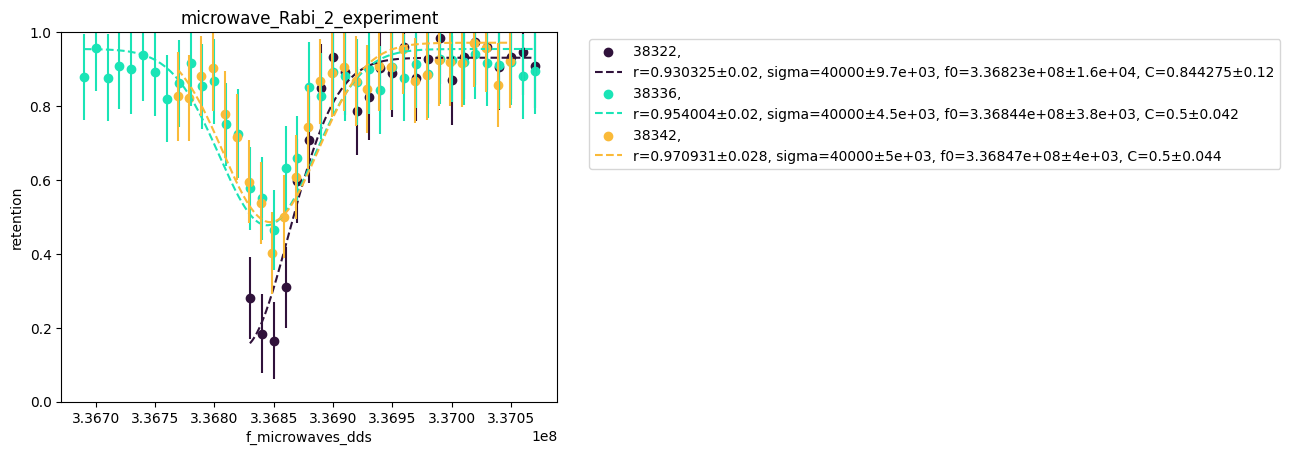

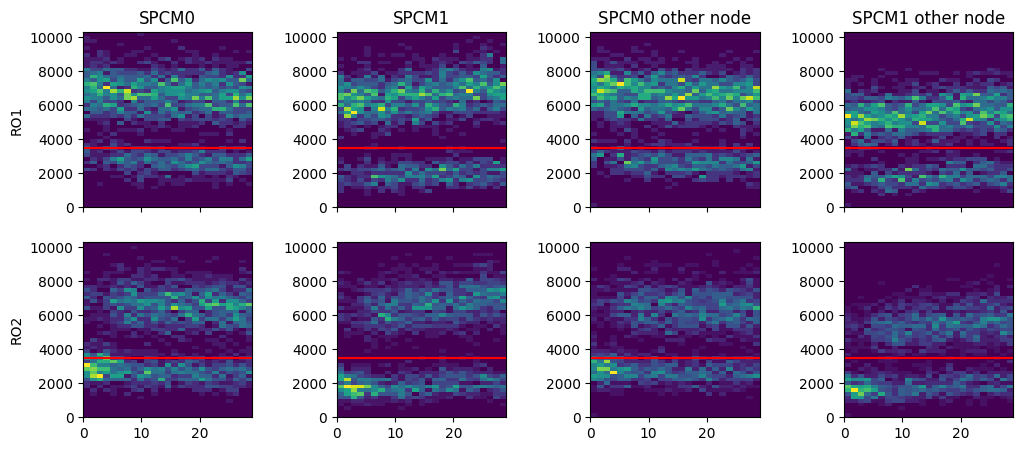

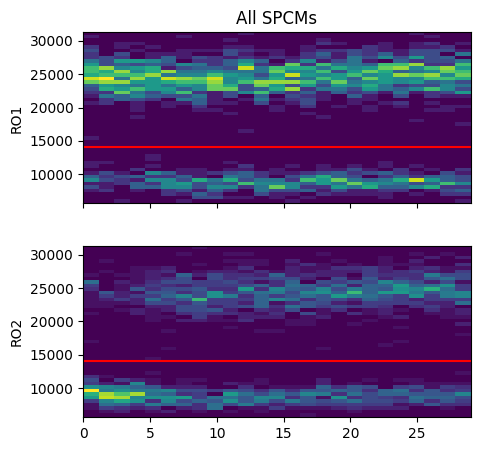

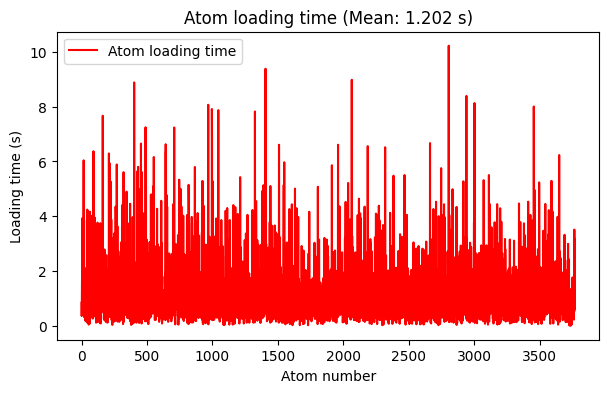

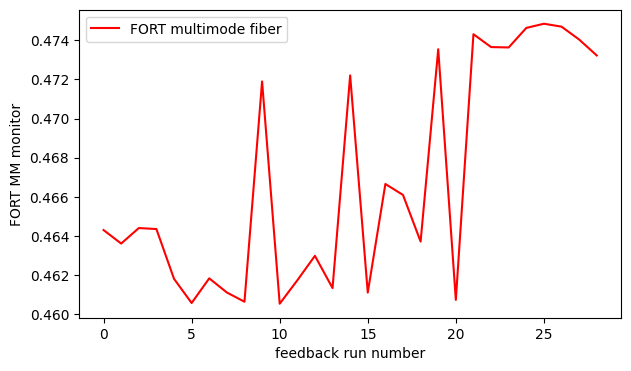

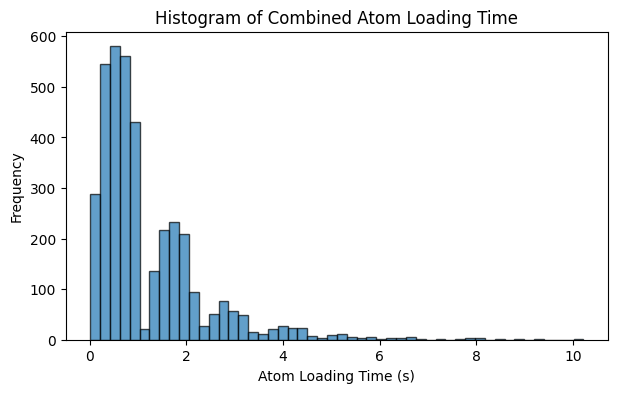

In [35]:
"""
"""
### the file(s) to analyze:
file_indices = {
    # 17:'', ##f
    # 18:'',
    # 20:''

    # 9: '',
    #  11: '',
    #  13: '',
    
     15: '',
     # 17: '',
     # 19: '',
     # 21: '',
     # 23: '',
     # 25: '',
     # 27: '',
     # 29: '',
     # 31: '',
     # 33: '',
     # 35: '',
     # 37: '',
     # 39: ''
    # 40:'20ms',
    
    42:'',
    46:'',
    # 50:''

} 

# file_indices = {i: '' for i in range(0, 17, 2)}

compare = True # compare multiple files in the same retention and loading plots

otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False

user_set_manual_threshold = 16000
manual_threshold = False


showhist = True
showloading = False
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = True # set True to fit recognized 1D microwave/RF/Ramsey scans

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
SPCM0_OtherNode_RO1_hists = []
SPCM0_OtherNode_RO2_hists = []
SPCM1_OtherNode_RO1_hists = []
SPCM1_OtherNode_RO2_hists = []
AllSPCMs_RO1_hists = []
AllSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''
fit_results = [] # one dictionary per successful fit

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    reset_scan_flags(locals())
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        thresh = threshold_otsu(AllSPCMs_RO1)

        print("threshold_otsu: ", thresh)
    elif manual_threshold:
        cutoff1 = cutoff2 = user_set_manual_threshold * t_SPCM_first_shot
    else:
        # cutoff1 = cutoff2 = 15000 * t_SPCM_first_shot

        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot
        # cutoff1 = cutoff2 = two_atom_threshold * t_SPCM_first_shot

    ensure_scan_flags_in_locals(locals())
    if fit:
        fit_for_this_freq, fit_for_this_sigma = get_scan_fit_guess_from_locals(locals())
        fit_dict = build_fit_dict(fit_for_this_freq, fit_for_this_sigma)
    else:
        fit_dict = {}

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(AllSPCMs_RO1, AllSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    # ### show historam of first_shot and second_shot
    # histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    # histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2, SPCM0_OtherNode_RO1, SPCM0_OtherNode_RO2, SPCM1_OtherNode_RO1, SPCM1_OtherNode_RO2])/t_SPCM_first_shot


    ### Histogram boundaries for individual SPCMs
    single_hist_sources = [
        np.asarray(SPCM0_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM0_OtherNode_RO1) / t_SPCM_first_shot,
        np.asarray(SPCM1_OtherNode_RO1) / t_SPCM_first_shot,
    
        np.asarray(SPCM0_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM0_OtherNode_RO2) / t_SPCM_second_shot,
        np.asarray(SPCM1_OtherNode_RO2) / t_SPCM_second_shot,
    ]
    
    single_hist_sources = [x.ravel() for x in single_hist_sources if x.size > 0]
    
    histMin_single = min(np.min(x) for x in single_hist_sources)
    histMax_single = max(np.max(x) for x in single_hist_sources)
    
    
    ### Histogram boundaries for AllSPCMs
    all_hist_sources = [
        np.asarray(AllSPCMs_RO1) / t_SPCM_first_shot,
        np.asarray(AllSPCMs_RO2) / t_SPCM_second_shot,
    ]
    
    all_hist_sources = [x.ravel() for x in all_hist_sources if x.size > 0]
    
    histMin_all = min(np.min(x) for x in all_hist_sources)
    histMax_all = max(np.max(x) for x in all_hist_sources)


    
    if showhist:
        bins_single = np.linspace(histMin_single, histMax_single, 50)
        bins_all = np.linspace(histMin_all, histMax_all, 50)
    
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO1_hists.append(
            [np.histogram(SPCM0_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM0_OtherNode_RO2_hists.append(
            [np.histogram(SPCM0_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO1_hists.append(
            [np.histogram(SPCM1_OtherNode_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        SPCM1_OtherNode_RO2_hists.append(
            [np.histogram(SPCM1_OtherNode_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_single)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO1_hists.append(
            [np.histogram(AllSPCMs_RO1[i*n_measurements:(i+1)*n_measurements] / t_SPCM_first_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )
    
        AllSPCMs_RO2_hists.append(
            [np.histogram(AllSPCMs_RO2[i*n_measurements:(i+1)*n_measurements] / t_SPCM_second_shot,
                          bins=bins_all)[0]
             for i in range(iterations)]
        )

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            if not ncols > 1 and fit:
                if scan_variable1_name in fit_dict:
                    try:
                        fit_spec = fit_dict[scan_variable1_name]
                        valid_fit = loading > 0
                        fit_result = fit_scan_data(scan_sequence1[valid_fit], retention[valid_fit], fit_spec)
                        fit_results.append({
                            "rid": rid,
                            "scan_variable": scan_variable1_name,
                            "params": dict(zip(fit_spec["params"], fit_result["popt"])),
                            "errors": dict(zip(fit_spec["params"], fit_result["perr"])),
                            **({"t_pi": fit_result["t_pi"], "t_pi_err": fit_result["t_pi_err"]} if "t_pi" in fit_result else {}),
                        })
                        print_fit_result(rid, scan_variable1_name, fit_spec, fit_result)
                        fit_str = format_fit_result(fit_spec, fit_result)
                        hi_res_x = np.linspace(np.min(fit_result["xdata"]), np.max(fit_result["xdata"]), 10*len(scan_sequence1))
                        ax_ret.plot(xsteps_xform(hi_res_x), fit_spec["model"](hi_res_x, *fit_result["popt"]), linestyle='--', color=ret_cmap(idx/len(file_indices)), label=fit_str)
                    except Exception as exc:
                        print(f"RID {rid} fit failed for {scan_variable1_name}: {exc}")
                        ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], linestyle='--', color=ret_cmap(idx/len(file_indices)))
                else:
                    print(f"No fit model configured for {scan_variable1_name}. Available models: {', '.join(fit_dict)}")
                    ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], linestyle='--', color=ret_cmap(idx/len(file_indices)))
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], linestyle='--', color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:
        try:
            fit_spec = fit_dict[scan_variable1_name]
            fit_result = fit_scan_data(scan_sequence1, retention, fit_spec)
            fit_results.append({
                "rid": rid_str[:-2],
                "scan_variable": scan_variable1_name,
                "params": dict(zip(fit_spec["params"], fit_result["popt"])),
                "errors": dict(zip(fit_spec["params"], fit_result["perr"])),
                **({"t_pi": fit_result["t_pi"], "t_pi_err": fit_result["t_pi_err"]} if "t_pi" in fit_result else {}),
            })
            print_fit_result(rid_str[:-2], scan_variable1_name, fit_spec, fit_result)
            fit_str = format_fit_result(fit_spec, fit_result)
            hi_res_x = np.linspace(np.min(fit_result["xdata"]), np.max(fit_result["xdata"]), 10*len(scan_sequence1))
            ax_ret.plot(xsteps_xform(hi_res_x), fit_spec["model"](hi_res_x, *fit_result["popt"]), linestyle='--', color='violet', label=fit_str)
            ax_ret.legend()
        except Exception as exc:
            print(f"Merged fit failed for {scan_variable1_name}: {exc}")
            ax_ret.plot(xsteps_xform(scan_sequence1), retention, linestyle='--', color='violet')
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention, linestyle='--', color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    ### Individual SPCM plots
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 5), sharex=True)
    ax, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.ravel()

    ### RO1: SPCM0
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower',
                    extent=[0, iterations, histMin_single, histMax_single])
    ax.set_ylabel("RO1")
    ax.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### RO1: SPCM1
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax2.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### RO1: SPCM0 Other Node
    cax3 = ax3.imshow(np.array(SPCM0_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax3.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("SPCM0 other node")

    ### RO1: SPCM1 Other Node
    cax4 = ax4.imshow(np.array(SPCM1_OtherNode_RO1_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax4.axhline((cutoff1 / 4) / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')
    ax4.set_title("SPCM1 other node")


    ### RO2: SPCM0
    cax5 = ax5.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax5.set_ylabel("RO2")
    ax5.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax5.set_aspect('auto')

    ### RO2: SPCM1
    cax6 = ax6.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax6.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax6.set_aspect('auto')

    ### RO2: SPCM0 Other Node
    cax7 = ax7.imshow(np.array(SPCM0_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax7.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax7.set_aspect('auto')

    ### RO2: SPCM1 Other Node
    cax8 = ax8.imshow(np.array(SPCM1_OtherNode_RO2_hists[0]).transpose(), origin='lower',
                      extent=[0, iterations, histMin_single, histMax_single])
    ax8.axhline((cutoff2 / 4) / t_SPCM_second_shot, color='red')
    ax8.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)


    ### All SPCMs plotted separately
    fig_all, axes_all = plt.subplots(nrows=2, ncols=1, figsize=(5, 5), sharex=True)
    ax_all1, ax_all2 = axes_all.ravel()

    ### RO1: All SPCMs
    cax_all1 = ax_all1.imshow(np.array(AllSPCMs_RO1_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all1.set_ylabel("RO1")
    ax_all1.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax_all1.set_aspect('auto')
    ax_all1.set_title("All SPCMs")

    ### RO2: All SPCMs
    cax_all2 = ax_all2.imshow(np.array(AllSPCMs_RO2_hists[0]).transpose(), origin='lower',
                              extent=[0, iterations, histMin_all, histMax_all])
    ax_all2.set_ylabel("RO2")
    ax_all2.axhline(cutoff2 / t_SPCM_second_shot, color='red')
    ax_all2.set_aspect('auto')

    plt.subplots_adjust(hspace=0.25)

plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = [t for loading_times in all_atom_loading_times for t in loading_times]
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()



### Atom Loading time - All selected files

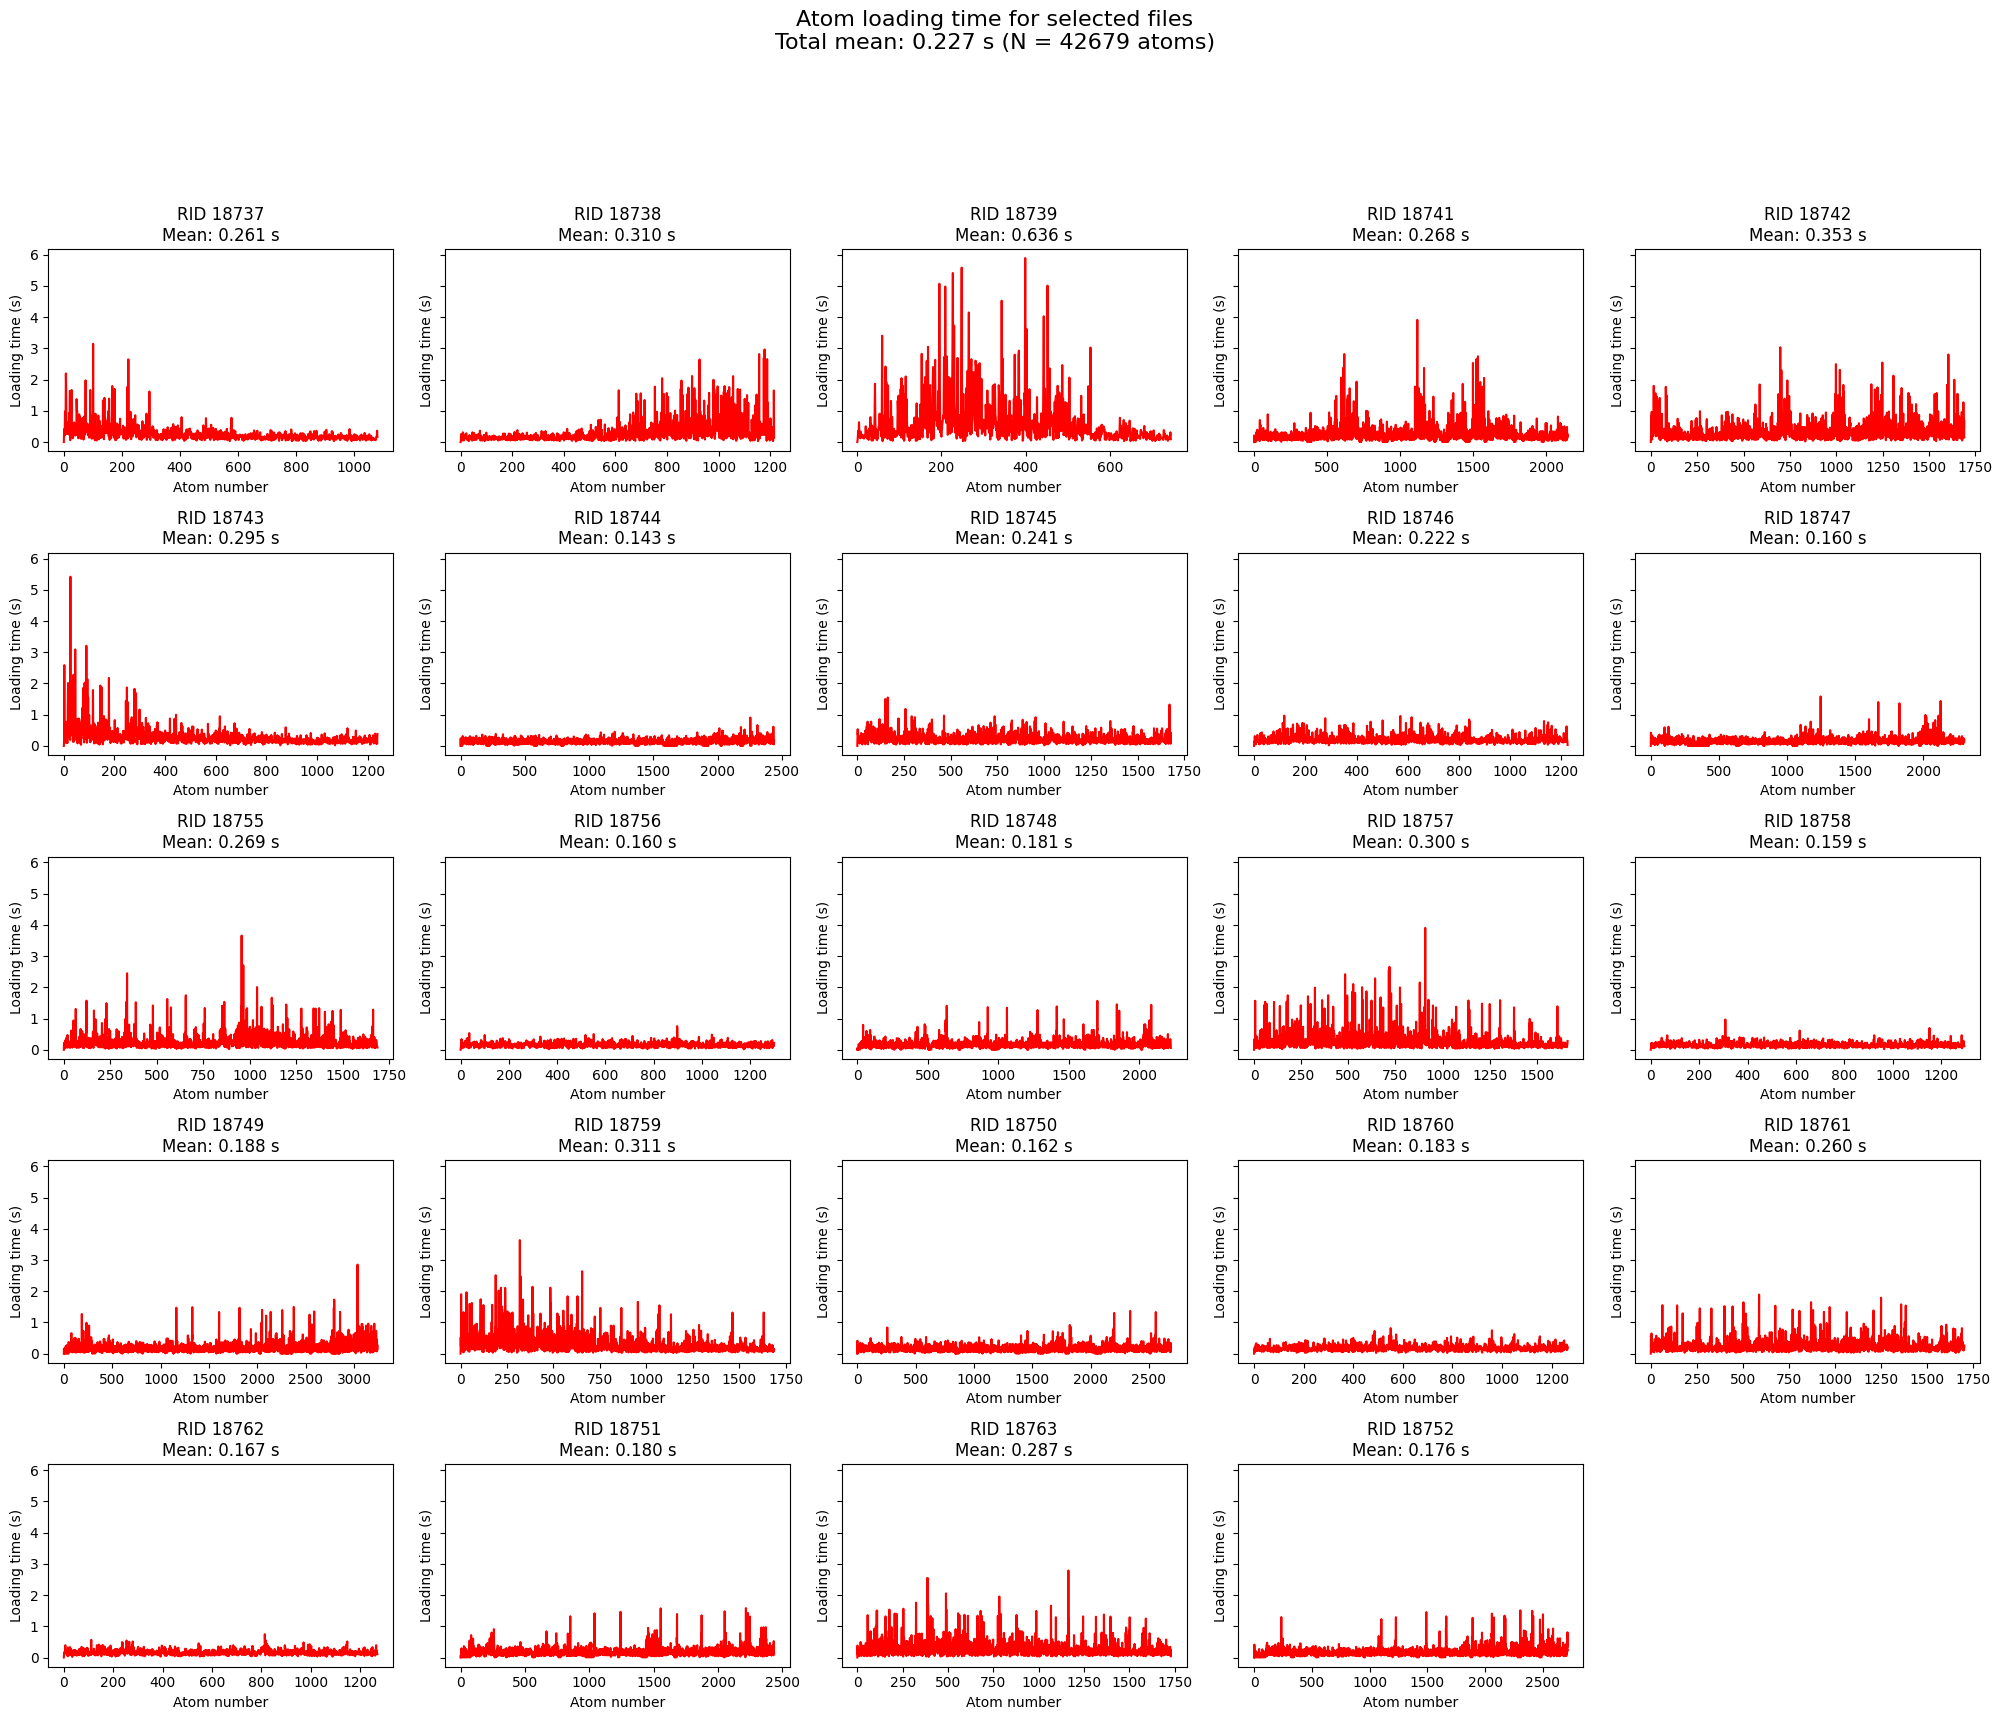

In [151]:
import os
import math
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_indices = {
    104: '',
     106: '',
     108: '',
     110: '',
     112: '',
     114: '',
     116: '',
     118: '',
     120: '',
     122: '',
     124: '',
     126: '',
     128: '',
     130: '',
     132: '',
     134: '',
     136: '',
     138: '',
     140: '',
     142: '',
     144: '',
     146: '',
     148: '',
     150: ''}
n_files = len(file_indices)
n_cols = 5
n_rows = math.ceil(n_files / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharey=True)
axs = np.atleast_1d(axs).ravel()

all_atom_loading_times = []

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):

    # Reload file
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]

    # Load datasets into a temporary dictionary
    d = {}
    h5_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)
    f.close()

    atom_loading_times = np.asarray(d["Atom_loading_time"], dtype=float).ravel()
    all_atom_loading_times.extend(atom_loading_times)

    mean_loading_time = np.mean(atom_loading_times)

    ax = axs[idx]
    ax.plot(atom_loading_times, "r-")
    ax.set_xlabel("Atom number")
    ax.set_ylabel("Loading time (s)")

    title = f"RID {rid}\nMean: {mean_loading_time:.3f} s"
    if f_comment:
        title += f"\n{f_comment}"

    ax.set_title(title)

# Hide unused subplots
for idx in range(n_files, len(axs)):
    axs[idx].set_visible(False)

# Mean over every atom-loading measurement from all selected files
all_atom_loading_times = np.asarray(all_atom_loading_times)
total_mean_loading_time = np.mean(all_atom_loading_times)

fig.suptitle(
    f"Atom loading time for selected files\n"
    f"Total mean: {total_mean_loading_time:.3f} s "
    f"(N = {len(all_atom_loading_times)} atoms)",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

### FORT power monitor

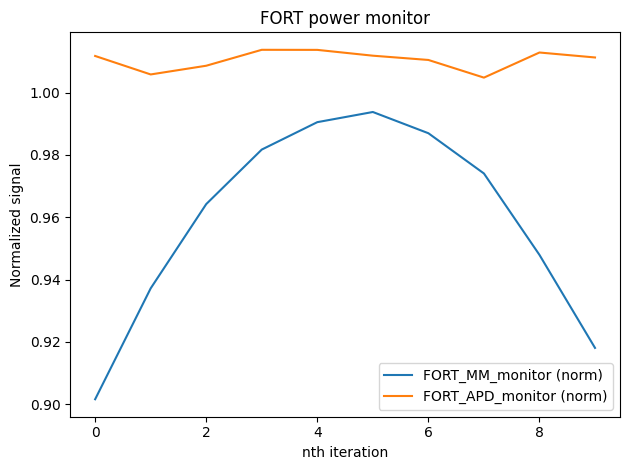

In [109]:
plt.figure()

plt.plot(
    FORT_MM_monitor / best_852_power_ref / (FORT_APD_monitor / set_point_FORT_APD_loading),
    label="FORT_MM_monitor (norm)"
)

plt.plot(
    FORT_APD_monitor / set_point_FORT_APD_loading,
    label="FORT_APD_monitor (norm)"
)

plt.xlabel("nth iteration")
plt.ylabel("Normalized signal")
plt.title("FORT power monitor")
# plt.ylim(0,1.1)
plt.legend()
plt.tight_layout()
plt.show()

### Normalized FORT monitor for all selected files

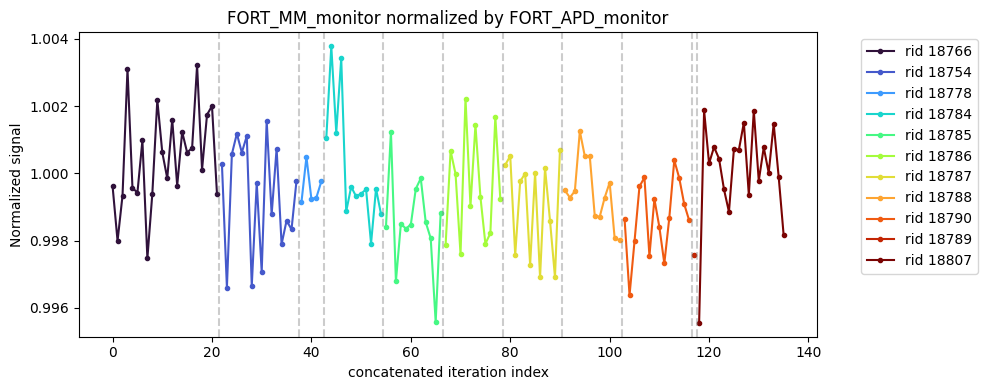

In [160]:
# --------------------------
# Plot normalized FORT monitor for all selected files
# with concatenated iteration index
# --------------------------

# file_indices = {
#     155: '',
#  157: '',
#  159: '',
#  161: '',
#  163: '',
#  165: '',
#  167: '',
#  169: '',
#  171: '',
#  173: '',
#  175: ''
# }

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

cmap = mpl.colormaps['turbo']
fig, ax = plt.subplots(figsize=(10, 4))

x_offset = 0   # change to 1 if you want the first point to start at 1

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):

    # reload file
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]

    # load datasets into a temporary dictionary
    d = {}
    h5_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)
    f.close()

    # get datasets
    FORT_MM = np.asarray(d["FORT_MM_monitor"]).ravel()
    FORT_APD = np.asarray(d["FORT_APD_monitor"]).ravel()

    best_ref = np.asarray(d["best_852_power_ref"]).squeeze()
    setpoint = np.asarray(d["set_point_FORT_APD_loading"]).squeeze()

    # normalized FORT MM signal
    norm_signal = FORT_MM / best_ref / (FORT_APD / setpoint)

    # x-axis: continue from previous experiment
    n_pts = len(norm_signal)
    x = np.arange(x_offset, x_offset + n_pts)

    color = cmap(idx / max(len(file_indices) - 1, 1))

    label = f"rid {rid}"
    if f_comment:
        label += f", {f_comment}"

    ax.plot(
        x,
        norm_signal,
        '.-',
        color=color,
        label=label
    )

    # optional vertical line showing file boundary
    if idx > 0:
        ax.axvline(
            x_offset - 0.5,
            color='gray',
            linestyle='--',
            alpha=0.4
        )

    # update offset so next file starts at last + 1
    x_offset += n_pts

ax.set_xlabel("concatenated iteration index")
ax.set_ylabel("Normalized signal")
ax.set_title("FORT_MM_monitor normalized by FORT_APD_monitor")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Magnetometer analysis - by measurement

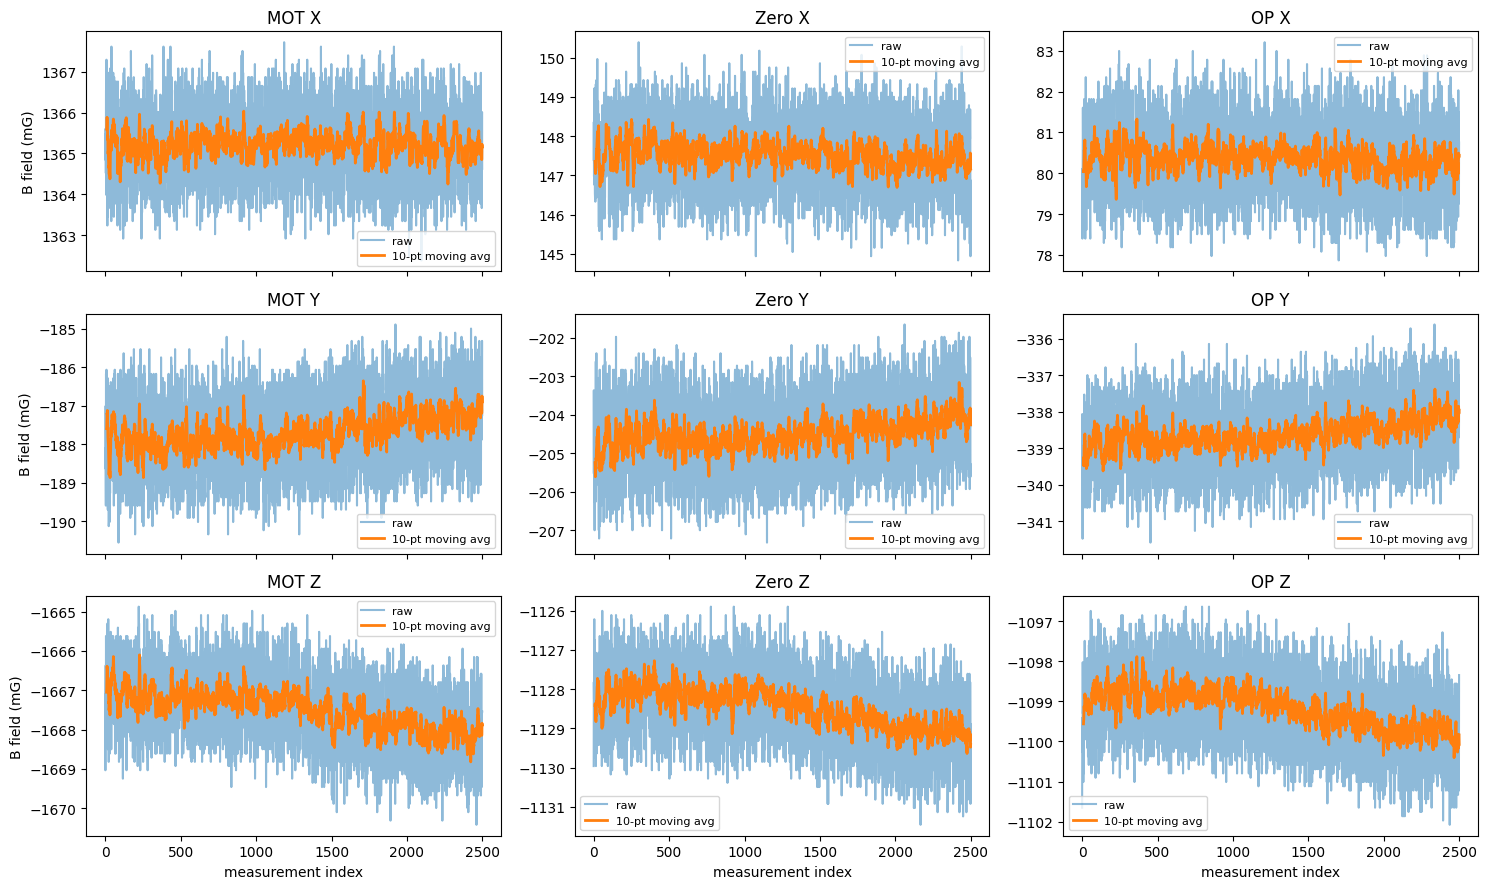

In [27]:
"""
Plot raw magnetometer data with a moving average on top.
Layout:
Row 1: MOT X, Zero X, OP X
Row 2: MOT Y, Zero Y, OP Y
Row 3: MOT Z, Zero Z, OP Z
"""

import numpy as np
import matplotlib.pyplot as plt

# Conversion factor: V -> mG
# V_to_mG = 625
V_to_mG = 1

# Moving average window
window = 10

# Reordered raw magnetometer data converted to mG
Magnetometer_data = [
    Magnetometer_MOT_X[1:] * V_to_mG,
    Magnetometer_Zero_X[1:] * V_to_mG,
    Magnetometer_OP_X[1:] * V_to_mG,

    Magnetometer_MOT_Y[1:] * V_to_mG,
    Magnetometer_Zero_Y[1:] * V_to_mG,
    Magnetometer_OP_Y[1:] * V_to_mG,

    Magnetometer_MOT_Z[1:] * V_to_mG,
    Magnetometer_Zero_Z[1:] * V_to_mG,
    Magnetometer_OP_Z[1:] * V_to_mG
]


display(HTML(f"""<b style='font-size:18px;'> RID {rid} - {experiment_function}</b>"""))

fig, axs = plt.subplots(3, 3, figsize=(15, 9), sharex=True, sharey=False)

titles = [
    "MOT X", "Zero X", "OP X",
    "MOT Y", "Zero Y", "OP Y",
    "MOT Z", "Zero Z", "OP Z",
]

ylabels = ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2
xlabels = [""] * 6 + ["measurement index"] * 3

for idx, raw_data in enumerate(Magnetometer_data):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]

    # raw data
    ax.plot(raw_data, '-', alpha=0.5, label='raw')

    # moving average
    if len(raw_data) >= window:
        smooth_data = np.convolve(raw_data, np.ones(window) / window, mode='valid')
        x_smooth = np.arange(window - 1, len(raw_data))
        ax.plot(x_smooth, smooth_data, linewidth=2, label=f'{window}-pt moving avg')

    ax.set_title(titles[idx])

    if ylabels[idx]:
        ax.set_ylabel(ylabels[idx])
    if xlabels[idx]:
        ax.set_xlabel(xlabels[idx])

    ax.legend(fontsize=8)

# ax.set_title(f"{locals().get('experiment_function', '')} {rid}")

plt.tight_layout()
plt.show()

# Magnetometer_MOT_X

### measure_Magnetometer_X_Y_Z

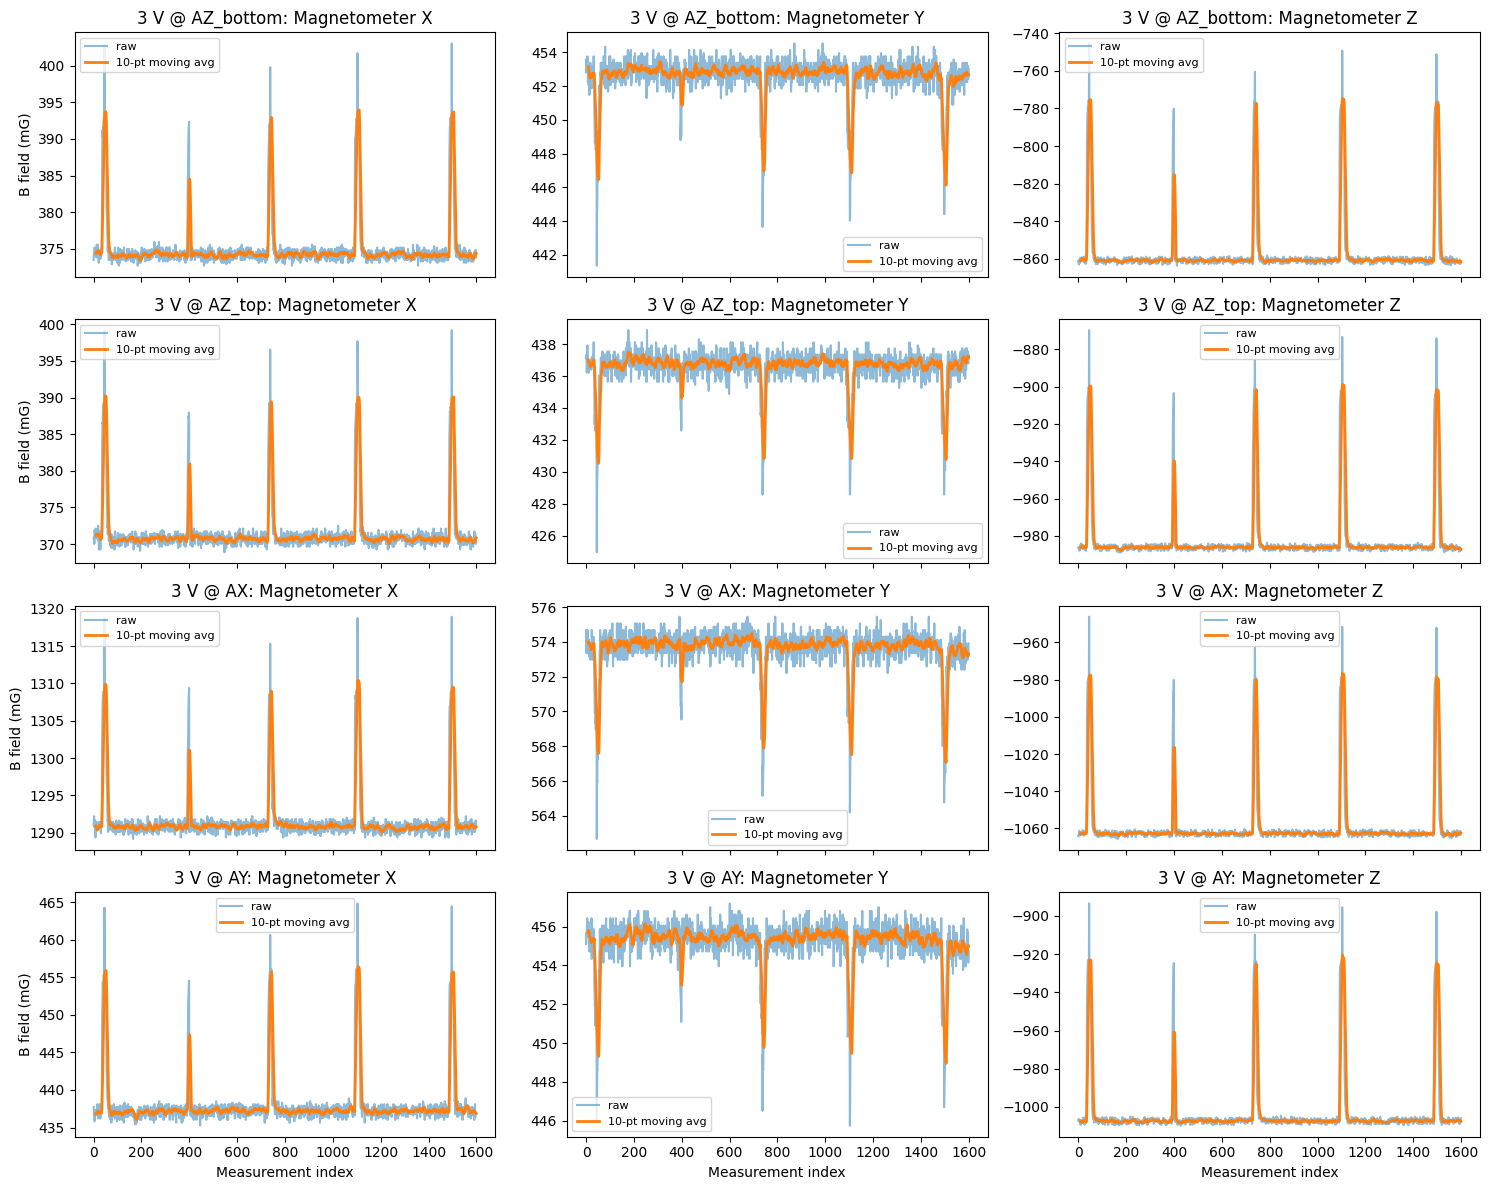

In [129]:
"""
Plot the magnetic field produced by each coil channel separately.

Layout:
Row 1: 3 V @ AZ_bottom → Magnetometer X, Y, Z
Row 2: 3 V @ AZ_top    → Magnetometer X, Y, Z
Row 3: 3 V @ AX        → Magnetometer X, Y, Z
Row 4: 3 V @ AY        → Magnetometer X, Y, Z
"""

import numpy as np
import matplotlib.pyplot as plt

V_to_mG = 625
window = 10

# Dataset mapping:
# Zero -> AZ_bottom
# OP   -> AZ_top
# MOT  -> AX
# TEST -> AY
Magnetometer_data = [
    [Magnetometer_Zero_X[1:] * V_to_mG, Magnetometer_Zero_Y[1:] * V_to_mG, Magnetometer_Zero_Z[1:] * V_to_mG],
    [Magnetometer_OP_X[1:] * V_to_mG, Magnetometer_OP_Y[1:] * V_to_mG, Magnetometer_OP_Z[1:] * V_to_mG],
    [Magnetometer_MOT_X[1:] * V_to_mG, Magnetometer_MOT_Y[1:] * V_to_mG, Magnetometer_MOT_Z[1:] * V_to_mG],
    [Magnetometer_TEST_X[1:] * V_to_mG, Magnetometer_TEST_Y[1:] * V_to_mG, Magnetometer_TEST_Z[1:] * V_to_mG],
]

coil_names = ["3 V @ AZ_bottom", "3 V @ AZ_top", "3 V @ AX", "3 V @ AY"]
magnetometer_axes = ["X", "Y", "Z"]

display(HTML(f"<b style='font-size:18px;'>RID {rid} - {experiment_function}</b>"))

fig, axs = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=False)

for row in range(4):
    for col in range(3):
        ax = axs[row, col]
        raw_data = np.asarray(Magnetometer_data[row][col])

        ax.plot(raw_data, "-", alpha=0.5, label="raw")

        if len(raw_data) >= window:
            smooth_data = np.convolve(raw_data, np.ones(window) / window, mode="valid")
            x_smooth = np.arange(window - 1, len(raw_data))
            ax.plot(x_smooth, smooth_data, linewidth=2, label=f"{window}-pt moving avg")

        ax.set_title(f"{coil_names[row]}: Magnetometer {magnetometer_axes[col]}")

        if col == 0:
            ax.set_ylabel("B field (mG)")

        if row == 3:
            ax.set_xlabel("Measurement index")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### measure_Magnetometer_X_Y_Z for all selected files

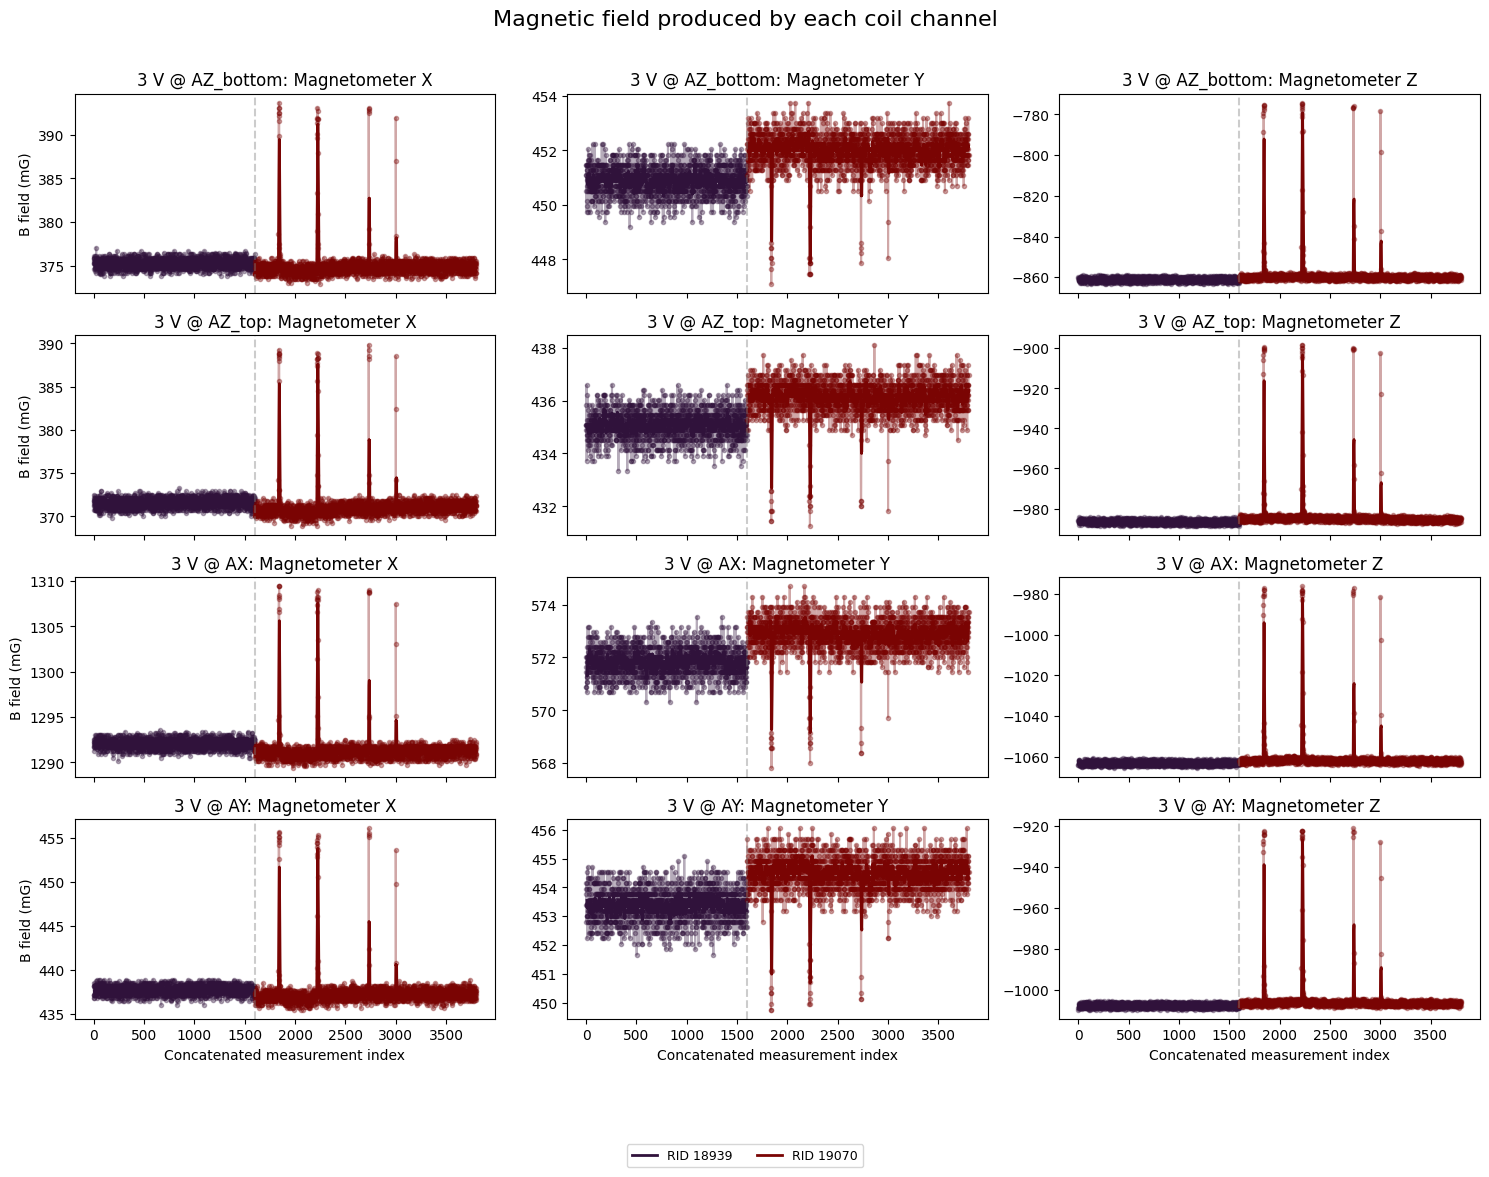

In [37]:
# --------------------------
# Plot magnetometer data from all selected files
# with concatenated measurement index
# and one shared legend at the bottom
# --------------------------

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


V_to_mG = 625
window = 10
skip_first_point = True  # Set False if index 0 is a real measurement

dataset_names = [
    ["Magnetometer_Zero_X", "Magnetometer_Zero_Y", "Magnetometer_Zero_Z"],
    ["Magnetometer_OP_X", "Magnetometer_OP_Y", "Magnetometer_OP_Z"],
    ["Magnetometer_MOT_X", "Magnetometer_MOT_Y", "Magnetometer_MOT_Z"],
    ["Magnetometer_TEST_X", "Magnetometer_TEST_Y", "Magnetometer_TEST_Z"],
]

coil_names = ["3 V @ AZ_bottom", "3 V @ AZ_top", "3 V @ AX", "3 V @ AY"]
magnetometer_axes = ["X", "Y", "Z"]

cmap = mpl.colormaps["turbo"]
fig, axs = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=False)

# Keep a separate cumulative index for every dataset
x_offsets = np.zeros((4, 3), dtype=int)

for idx, (f_idx, f_comment) in enumerate(file_indices.items()):

    # Reload file
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f["rid"][()]

    # Load datasets into a temporary dictionary
    d = {}
    h5_archive_and_datasets_to_locals(f, parent_locals=d, quiet=True)
    f.close()

    color = cmap(idx / max(len(file_indices) - 1, 1))

    label = f"RID {rid}"
    if f_comment:
        label += f", {f_comment}"

    for row in range(4):
        for col in range(3):
            ax = axs[row, col]

            raw_data = np.asarray(d[dataset_names[row][col]]).ravel()

            if skip_first_point:
                raw_data = raw_data[1:]

            raw_data = raw_data * V_to_mG
            n_pts = len(raw_data)

            start = x_offsets[row, col]
            stop = start + n_pts
            x = np.arange(start, stop)

            # Raw data, excluded from legend
            ax.plot(x, raw_data, ".-", color=color, alpha=0.35, label="_nolegend_")

            # Moving average
            if n_pts >= window:
                smooth_data = np.convolve(raw_data, np.ones(window) / window, mode="valid")
                legend_label = label if row == 0 and col == 0 else "_nolegend_"
                ax.plot(x[window - 1:], smooth_data, "-", color=color, linewidth=2, label=legend_label)

            # If there are too few points for a moving average
            elif row == 0 and col == 0:
                ax.plot([], [], "-", color=color, linewidth=2, label=label)

            # File boundary
            if start > 0:
                ax.axvline(start - 0.5, color="gray", linestyle="--", alpha=0.4)

            # Next file starts at the next measurement index
            x_offsets[row, col] = stop

for row in range(4):
    for col in range(3):
        ax = axs[row, col]
        ax.set_title(f"{coil_names[row]}: Magnetometer {magnetometer_axes[col]}")

        if col == 0:
            ax.set_ylabel("B field (mG)")

        if row == 3:
            ax.set_xlabel("Concatenated measurement index")

# One shared legend for the whole figure
handles, labels = axs[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=5,
    fontsize=9,
    frameon=True,
)

fig.suptitle("Magnetic field produced by each coil channel", fontsize=16)

# Reserve space for the title and bottom legend
plt.tight_layout(rect=[0, 0.09, 1, 0.97])
plt.show()

### AOM RF power analysis

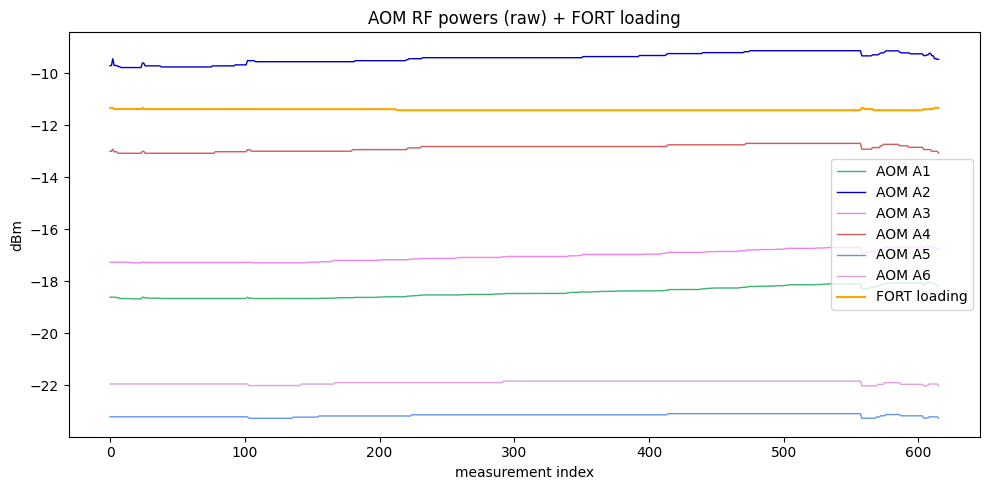

In [112]:
"""AOM RF powers (raw) + FORT loading power in the same plot"""

import numpy as np
import matplotlib.pyplot as plt

aom_colors = [
    'mediumseagreen', 'mediumblue', 'violet', 'indianred', 'cornflowerblue',
    'plum', 'tomato', 'chartreuse', 'g', 'aquamarine', 'salmon',
    'b', 'dodgerblue', 'crimson', 'darkgreen', 'orange', 'magenta',
    'cyan', 'purple', 'royalblue', 'lime', 'cornflowerblue', 'pink'
]

n_aoms = 6

plt.figure(figsize=(10, 5))

for i in range(n_aoms):
    RF_history = np.array(locals()[f'p_AOM_A{i+1}_history'])
    plt.plot(RF_history, color=aom_colors[i], label=f'AOM A{i+1}', lw=1)

# Add FORT loading history
plt.plot(
    np.array(p_FORT_loading_history),
    color='orange',
    label='FORT loading',
    lw=1.5
)

plt.xlabel("measurement index")
plt.ylabel("dBm")
plt.title("AOM RF powers (raw) + FORT loading")
plt.legend()
plt.tight_layout()
plt.show()